Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0

# BUS-BRA Breast Ultrasound — Tumor Segmentation with MONAI

This notebook builds a binary tumor-segmentation pipeline on top of the BUS-BRA dataset using **MONAI** end-to-end: transforms, dataset, U-Net, loss, metric, and training loop.

Every design choice in this notebook is **driven by the gating results** from the companion data-quality snapshot:

| data-quality Snapshot finding | Pipeline choice |
| --- | --- |
| Hundreds of distinct (W, H) resolutions | Fixed **256×256 resize** is mandatory |
| Global background : foreground ≈ 10.6 : 1 | **`DiceCELoss`** (sigmoid, single-channel output) |
| Wide per-image intensity spread | **`ScaleIntensityd`** to a common 0–1 range |
| 1875 images from 1064 patients (paired views) | **Patient-grouped split via the predefined `K5P` folds** |
| Masks are single-connected-component | No keep-largest post-processing needed |
| Images are 8-bit `L`; masks are 1-bit `1` | Channel-first + binarise label after load |

**Target task:** Binary tumor segmentation (tumor vs. background)  
**Modality:** Breast Ultrasound (B-mode)  
**Dataset:** [BUS-BRA](https://www.kaggle.com/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/data)  
**Author:** Lakshmi Mahabaleshwara

## Audience and prerequisites

Written for **ML practitioners new to MONAI** and **beginners learning medical segmentation**. Assumes Python + PyTorch fluency at the level of basic training loops; explains MONAI-specific concepts (dictionary transforms, the `Dataset`/`DataLoader` split, `DiceCELoss`, `DiceMetric`) as they come up.

## What this notebook does — and does not — do

This notebook trains a **single-fold baseline** to show the full pipeline working: one fold of `K5P` is held out for validation; the other four are used for training. Full 5-fold CV is a straightforward loop on top — left as a follow-up so the first read stays linear.


## 1. Environment & setup


### §1.1 — Detecting the platform

**What this cell does:** Detects whether the notebook is running on Kaggle, Colab, or local.

**Why:** The dataset path differs by platform. On Kaggle the data lands under `/kaggle/input/...`. Centralising detection keeps every downstream path reference clean.


In [1]:
import os
import sys
from pathlib import Path


def detect_environment() -> str:
    """Return one of 'kaggle', 'colab', 'local'."""
    if os.path.exists("/kaggle/input"):
        return "kaggle"
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        pass
    return "local"


ENV = detect_environment()
print(f"Detected environment: {ENV}")


Detected environment: kaggle


### §1.2 — Installing dependencies

**What this cell does:** Installs MONAI and its companions. PyTorch, NumPy, Pillow, and Matplotlib ship on Kaggle/Colab by default; MONAI usually does not.

**Why:** This notebook uses MONAI for *everything* segmentation-specific — `LoadImaged`, `EnsureChannelFirstd`, `Resized`, `ScaleIntensityd`, `RandFlipd`, `Dataset`, `UNet`, `DiceCELoss`, `DiceMetric`, `Activations`, `AsDiscrete`. `kagglehub` is the fallback to self-download the dataset if it isn't already attached.

> On Kaggle, enable **Internet** in the notebook settings (right sidebar) so the `pip install` and `kagglehub` calls can run, and switch the **Accelerator** to a GPU (T4 ×1 is plenty).


In [2]:
# MONAI and kagglehub are the two things not preinstalled on Kaggle by default.
%pip install -q monai==1.4.0 kagglehub 2>/dev/null

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader

import monai
from monai.data import Dataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    Resized,
    AsDiscreted,
    RandFlipd,
    EnsureTyped,
    Activations,
    AsDiscrete,
)
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.utils import set_determinism

print("torch", torch.__version__, "| monai", monai.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Note: you may need to restart the kernel to use updated packages.
torch 2.10.0+cpu | monai 1.4.0
CUDA available: False


### §1.3 — Reproducibility & device

**What this cell does:** Pins the random seeds (Python, NumPy, PyTorch, MONAI) and picks the compute device.

**Why:** Determinism makes training-curve comparisons across runs meaningful. `set_determinism` is MONAI's one-call wrapper for all four RNGs. The seed itself sits in the config (§2) so it can be swept without touching this cell.


In [3]:
SEED = 0
set_determinism(seed=SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 2. Config


### §2.1 — Defining the config

**What this cell does:** Declares a single `TrainConfig` dataclass holding every knob — paths, image size, fold selection, batch size, optimiser hyper-parameters, U-Net architecture, and epochs.

**Why:** One source of truth. Every later cell reads from `cfg` rather than hard-coding constants, so re-running an experiment with a different fold, image size, or learning rate is a single edit here.


In [4]:
from dataclasses import dataclass, field
from typing import Optional, Tuple


@dataclass
class TrainConfig:
    # --- data ---
    data_root: Optional[Path] = None   # Resolved in §3
    images_dirname: str = "Images"
    masks_dirname: str = "Masks"
    csv_name: str = "bus_data.csv"

    # --- split ---
    fold_column: str = "K5P"     # Predefined patient-grouped 5-fold
    val_fold: int = 1            # Which fold to hold out for validation

    # --- transforms ---
    image_size: Tuple[int, int] = (256, 256)

    # --- dataloader ---
    batch_size: int = 16
    num_workers: int = 2
    pin_memory: bool = True

    # --- model (MONAI UNet) ---
    unet_channels: Tuple[int, ...] = (16, 32, 64, 128, 256)
    unet_strides: Tuple[int, ...] = (2, 2, 2, 2)
    unet_num_res_units: int = 2

    # --- optimisation ---
    lr: float = 1e-3
    epochs: int = 30
    use_amp: bool = True         # Mixed precision (faster on T4/V100/A100)

    # --- bookkeeping ---
    seed: int = 0
    ckpt_path: str = "best_model.pt"


cfg = TrainConfig()
print(cfg)


TrainConfig(data_root=None, images_dirname='Images', masks_dirname='Masks', csv_name='bus_data.csv', fold_column='K5P', val_fold=1, image_size=(256, 256), batch_size=16, num_workers=2, pin_memory=True, unet_channels=(16, 32, 64, 128, 256), unet_strides=(2, 2, 2, 2), unet_num_res_units=2, lr=0.001, epochs=30, use_amp=True, seed=0, ckpt_path='best_model.pt')


## 3. Dataset access


### §3.1 — Resolving the dataset path

**What this cell does:** Locates the canonical data folder — the one containing `Images/`, `Masks/`, and `bus_data.csv`. First searches local/attached paths case-insensitively; if nothing is found, **falls back to downloading the dataset directly via `kagglehub`**.

**Why:** The `orvile` Kaggle re-upload may nest folders differently depending on how it's attached. Searching case-insensitively for the three known children removes that fragility, and the `kagglehub` fallback lets the notebook work on Colab/local without any manual download step.


In [5]:
def _dir_has(path: Path, name: str) -> bool:
    """Case-insensitive check for a child entry."""
    if not path.is_dir():
        return False
    lname = name.lower()
    return any(c.name.lower() == lname for c in path.iterdir())


def _looks_like_data_root(path: Path) -> bool:
    """A valid root has Images/, Masks/, and the CSV (case-insensitive)."""
    return (
        _dir_has(path, cfg.images_dirname)
        and _dir_has(path, cfg.masks_dirname)
        and _dir_has(path, cfg.csv_name)
    )


def _resolve_child(path: Path, name: str) -> Path:
    """Return the actual child path matching `name` case-insensitively."""
    lname = name.lower()
    for c in path.iterdir():
        if c.name.lower() == lname:
            return c
    return path / name  # fallback


def _search_for_root(base: Path) -> Optional[Path]:
    """Scan base and all its subdirectories for a valid data root."""
    if not base.exists():
        return None
    for candidate in [base] + [p for p in base.rglob("*") if p.is_dir()]:
        if _looks_like_data_root(candidate):
            return candidate
    return None


def resolve_data_root() -> Path:
    # 1) Look in attached/local locations first.
    search_base = Path("/kaggle/input") if ENV == "kaggle" else Path(".")
    found = _search_for_root(search_base)
    if found is not None:
        print(f"Found dataset locally at: {found}")
        return found

    # 2) Fallback: download via kagglehub (needs Internet enabled).
    print("Not found locally. Attempting kagglehub download...")
    try:
        import kagglehub
    except ImportError as e:
        raise RuntimeError(
            "kagglehub not installed and dataset not found locally. "
            "Either attach the BUS-BRA dataset via 'Add Input', or "
            "install kagglehub (pip install kagglehub) with Internet enabled."
        ) from e

    downloaded = Path(kagglehub.dataset_download(
        "orvile/bus-bra-a-breast-ultrasound-dataset"))
    found = _search_for_root(downloaded)
    if found is not None:
        print(f"Downloaded to: {found}")
        return found
    raise FileNotFoundError(
        f"Downloaded to {downloaded} but could not locate a folder "
        f"containing Images/, Masks/, and {cfg.csv_name} inside it. "
        "Inspect the printed path and adjust cfg if the layout differs."
    )


cfg.data_root = resolve_data_root()
IMAGES = _resolve_child(cfg.data_root, cfg.images_dirname)
MASKS = _resolve_child(cfg.data_root, cfg.masks_dirname)
print("Data root :", cfg.data_root)
print("Images dir:", IMAGES)
print("Masks dir :", MASKS)


Not found locally. Attempting kagglehub download...
Downloaded to: /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA
Data root : /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA
Images dir: /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA/Images
Masks dir : /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA/Masks


## 4. Manifest & patient-grouped split


### §4.1 — Building the manifest

**What this cell does:** Reads `bus_data.csv`, derives `image_path` and `mask_path` for every row, and stores everything as a list of `{"image": ..., "label": ...}` dictionaries — the shape MONAI's dictionary transforms expect.

**Why:** MONAI's dictionary pipeline (`LoadImaged`, `Resized`, ...) operates on dicts keyed by name (`"image"`, `"label"`), not on positional tuples. Building the manifest once and reusing it for both splits keeps the path logic in one place.


In [6]:
df = pd.read_csv(cfg.data_root / cfg.csv_name)


def image_path(image_id: str) -> Path:
    return IMAGES / f"{image_id}.png"


def mask_path(image_id: str) -> Path:
    # 'bus_0001-l' -> 'mask_0001-l'
    suffix = image_id.split("bus_")[1]
    return MASKS / f"mask_{suffix}.png"


df["image_path"] = df["ID"].map(image_path)
df["mask_path"] = df["ID"].map(mask_path)
manifest = df

print(f"Manifest rows: {len(manifest)}")
print(f"Columns      : {list(manifest.columns)}")
manifest[["ID", "Case", "Pathology", cfg.fold_column, "image_path", "mask_path"]].head(3)


Manifest rows: 1875
Columns      : ['ID', 'Case', 'Histology', 'Pathology', 'BIRADS', 'Device', 'Width', 'Height', 'Side', 'HOB', 'K5B', 'K10B', 'HOP', 'K5P', 'K10P', 'BBOX', 'image_path', 'mask_path']


,ID,Case,Pathology,K5P,image_path,mask_path
0,bus_0001-l,1,malignant,3,/kaggle/input/datasets/orvile/bus-bra-a-breast...,/kaggle/input/datasets/orvile/bus-bra-a-breast...
1,bus_0001-r,1,malignant,3,/kaggle/input/datasets/orvile/bus-bra-a-breast...,/kaggle/input/datasets/orvile/bus-bra-a-breast...
2,bus_0002-l,2,benign,5,/kaggle/input/datasets/orvile/bus-bra-a-breast...,/kaggle/input/datasets/orvile/bus-bra-a-breast...


### §4.2 — Patient-grouped split via K5P

**What this cell does:** Splits the manifest into train and validation using one fold of the predefined `K5P` (5-fold patient-grouped) assignment. All rows where `K5P == cfg.val_fold` go to validation; the rest become training.

**Why:** The BUS-BRA authors already constructed leakage-free folds — `K5P` guarantees that **no patient appears in both training and validation**, even though many patients contribute left + right images. Re-using their folds is faster, more reproducible, and less error-prone than building a `GroupKFold` from scratch. The `assert` is a check that the K5P column does what it claims.


In [7]:
train_df = manifest[manifest[cfg.fold_column] != cfg.val_fold].reset_index(drop=True)
val_df   = manifest[manifest[cfg.fold_column] == cfg.val_fold].reset_index(drop=True)

# Sanity: no patient should appear in both splits.
train_patients = set(train_df["Case"])
val_patients   = set(val_df["Case"])
overlap = train_patients & val_patients
assert not overlap, f"Patient leakage between train and val: {overlap}"

print(f"Train: {len(train_df):4d} images from {len(train_patients):4d} patients")
print(f"Val  : {len(val_df):4d} images from {len(val_patients):4d} patients")
print(f"Patient overlap: {len(overlap)}  (must be 0)")

# Convert to MONAI dict format.
def to_records(d: pd.DataFrame):
    return [{"image": str(r.image_path), "label": str(r.mask_path)}
            for r in d.itertuples()]

train_records = to_records(train_df)
val_records   = to_records(val_df)


Train: 1499 images from  852 patients
Val  :  376 images from  212 patients
Patient overlap: 0  (must be 0)


## 5. Transforms


### §5.1 — Train and validation transforms

**What this cell does:** Builds two transform pipelines. Both load + binarise + resize + normalise; only the training pipeline adds a random horizontal flip.

**Why each step is here:**

| Transform | Purpose |
| --- | --- |
| `LoadImaged(reader="PILReader")` | Reads PNGs through Pillow — works for both 8-bit grayscale (`L`) images and 1-bit (`1`) masks |
| `EnsureChannelFirstd` | Converts `(H, W)` → `(1, H, W)`; PyTorch/MONAI expect channel-first tensors |
| `ScaleIntensityd(keys="image")` | Maps the image to `[0, 1]`. Per the quality check snapshot, per-image brightness varies widely → normalisation is non-optional |
| `AsDiscreted(keys="label", threshold=0.5)` | Forces the mask to a clean `{0, 1}` float tensor regardless of whether PIL returned booleans or `0/255` uint8 |
| `Resized(..., mode=("bilinear", "nearest"))` | 256×256, the size the quality check snapshot's geometry check fixed. Image uses bilinear (smooth) interpolation; mask uses nearest-neighbour so labels stay integer-valued |
| `RandFlipd(spatial_axis=1, prob=0.5)` *(train only)* | Horizontal flip — safe for breast US because the probe orientation has no fixed left/right semantics. **Vertical flip is intentionally omitted** because the probe-skin interface is always at the top of the image |
| `EnsureTyped(dtype=torch.float32)` | Final dtype guarantee — both image and label are float tensors ready for the network |

**Augmentation choices kept minimal.** A single random flip is enough on a dataset this size. More aggressive augmentation (rotation, blur, intensity jitter) can be layered on later, but the gain is not free — past experiments on small ultrasound datasets have shown that some of these augmentations *hurt* Dice. Start minimal, measure, then add.


In [8]:
LOAD_AND_PREPARE = [
    LoadImaged(keys=["image", "label"], reader="PILReader", image_only=True),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys="image"),
    AsDiscreted(keys="label", threshold=0.5),
    Resized(
        keys=["image", "label"],
        spatial_size=cfg.image_size,
        mode=("bilinear", "nearest"),
    ),
]

train_transforms = Compose(LOAD_AND_PREPARE + [
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),  # horizontal
    EnsureTyped(keys=["image", "label"], dtype=torch.float32),
])

val_transforms = Compose(LOAD_AND_PREPARE + [
    EnsureTyped(keys=["image", "label"], dtype=torch.float32),
])

print("Train transforms:", len(train_transforms.transforms), "steps")
print("Val   transforms:", len(val_transforms.transforms), "steps")


Train transforms: 7 steps
Val   transforms: 6 steps


## 6. Dataset & DataLoader


### §6.1 — Wrapping records in a MONAI `Dataset`

**What this cell does:** Wraps the train and validation record lists in `monai.data.Dataset` and exposes them through PyTorch `DataLoader`s.

**Why `Dataset` and not `CacheDataset`:** `CacheDataset` pre-applies the deterministic transforms once and keeps the result in memory — a big speed-up when transforms are expensive (e.g. 3D loads, complex spatial ops). For 2D PNGs at 256×256 the per-sample cost is already tiny, so plain `Dataset` (lazy, no extra RAM) is the simpler default. Switching to `CacheDataset(data=train_records, transform=train_transforms, cache_rate=1.0)` is a one-line change if profiling shows the data loader as the bottleneck.


In [9]:
train_ds = Dataset(data=train_records, transform=train_transforms)
val_ds   = Dataset(data=val_records,   transform=val_transforms)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
)

print(f"Train batches/epoch: {len(train_loader)}")
print(f"Val   batches      : {len(val_loader)}")


Train batches/epoch: 93
Val   batches      : 24


### §6.2 — Sanity-check one batch

**What this cell does:** Pulls one training batch, prints tensor shapes and value ranges, and renders the first four image/mask pairs.

**Why:** Catches the classes of bug that silently destroy training — wrong tensor shape (e.g. `(B, H, W)` instead of `(B, 1, H, W)`), images outside `[0, 1]`, masks that aren't `{0, 1}`, or misaligned image–mask pairs from a path-construction bug.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


image shape : (16, 1, 256, 256)  dtype torch.float32  range [0.000, 1.000]
label shape : (16, 1, 256, 256)  dtype torch.float32  unique [0.0, 1.0]


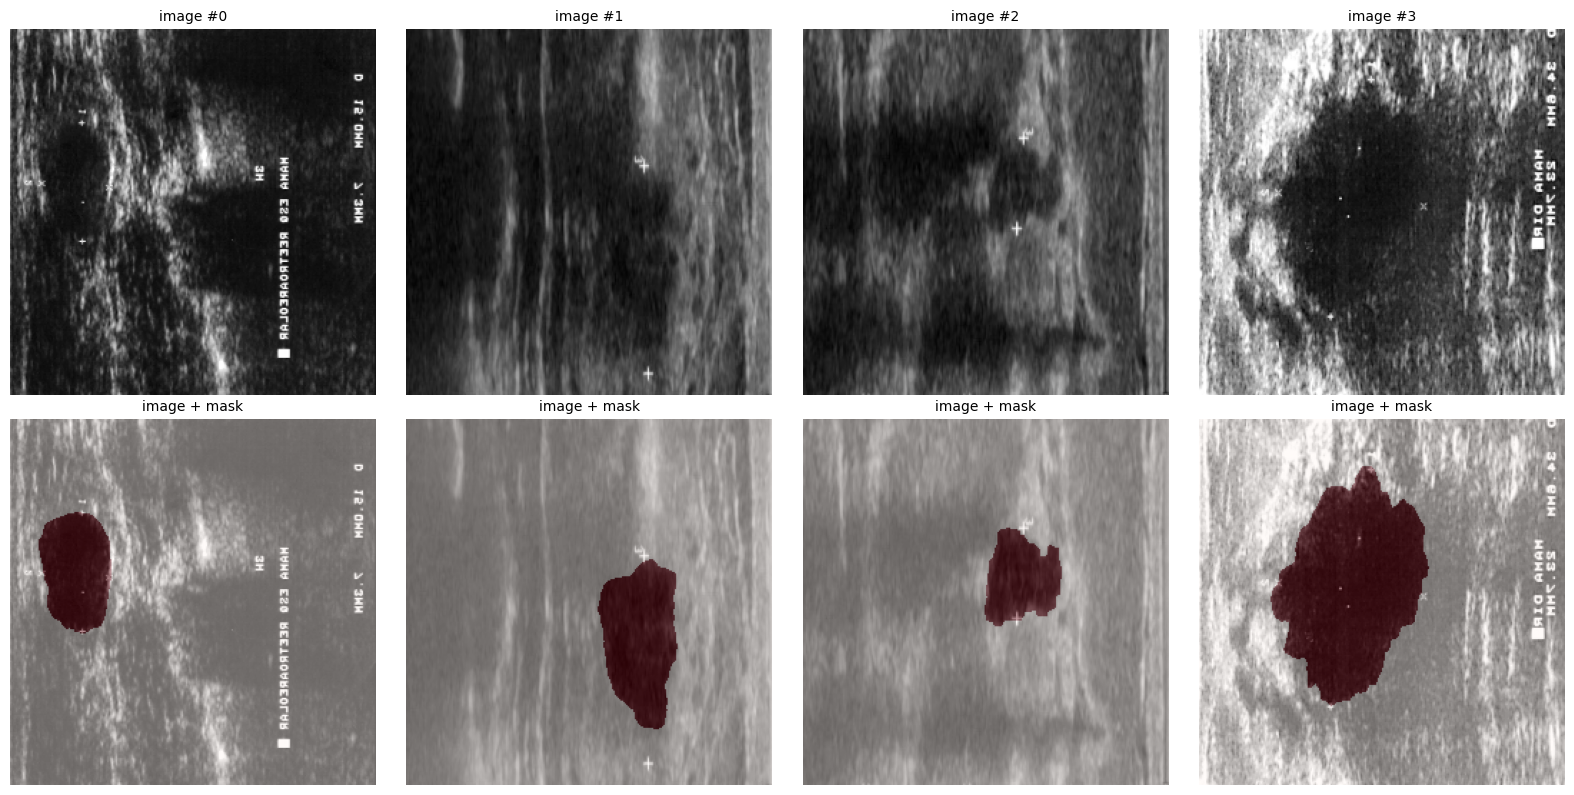

In [10]:
batch = next(iter(train_loader))
img, lab = batch["image"], batch["label"]

print(f"image shape : {tuple(img.shape)}  dtype {img.dtype}  range [{img.min():.3f}, {img.max():.3f}]")
print(f"label shape : {tuple(lab.shape)}  dtype {lab.dtype}  unique {torch.unique(lab).tolist()}")

n_show = min(4, img.shape[0])
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for j in range(n_show):
    axes[0, j].imshow(img[j, 0].cpu().numpy(), cmap="gray")
    axes[0, j].set_title(f"image #{j}", fontsize=10); axes[0, j].axis("off")
    axes[1, j].imshow(img[j, 0].cpu().numpy(), cmap="gray")
    axes[1, j].imshow(lab[j, 0].cpu().numpy(), cmap="Reds", alpha=0.4)
    axes[1, j].set_title("image + mask", fontsize=10); axes[1, j].axis("off")
plt.tight_layout(); plt.show()


## 7. Model, loss, optimiser, metric


### §7.1 — U-Net + `DiceCELoss` + `DiceMetric`

**What this cell does:** Assembles every component the training loop needs:

- **Model.** A MONAI `UNet` with five resolution levels (`channels=(16, 32, 64, 128, 256)`, `strides=(2, 2, 2, 2)`). One input channel (grayscale), one output channel (tumor logit).
- **Loss.** `DiceCELoss(sigmoid=True)` — Dice + binary cross-entropy on the same single-channel sigmoid output. `sigmoid=True` tells the loss to apply the activation itself, so the model produces raw logits.
- **Optimiser.** Plain `Adam` at `cfg.lr`. Nothing fancy: this is a baseline, and a clean optimiser makes the baseline numbers easy to read.
- **Metric.** `DiceMetric(include_background=True)` — with a single foreground channel, "include_background" simply means "report Dice on that one channel" (the tumor). No channel is being silently dropped.
- **Post-prediction.** A `Compose` that applies sigmoid and thresholds at 0.5 — used at validation time to turn logits into the binary masks the metric compares against ground truth.

**Why this loss specifically:** The quality check snapshot's class-balance check measured a background: foreground ratio of about 10.6: 1. A pure pixel-wise BCE on that imbalance collapses to predicting all-background (and gets ~91 % accuracy). Dice is scale-invariant in the foreground area, so it pushes the network actually to find the tumor; CE adds a smoother gradient signal where Dice is flat. The combination is MONAI's standard recommendation for imbalanced binary segmentation.


In [12]:
model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=cfg.unet_channels,
    strides=cfg.unet_strides,
    num_res_units=cfg.unet_num_res_units,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"UNet parameters: {n_params/1e6:.2f}M")

loss_fn   = DiceCELoss(sigmoid=True, lambda_dice=1.0, lambda_ce=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
dice_metric = DiceMetric(include_background=True, reduction="mean")

post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

# AMP setup (a no-op on CPU).
scaler = torch.amp.GradScaler("cuda", enabled=(cfg.use_amp and DEVICE.type == "cuda"))


UNet parameters: 1.62M


## 8. Training


### §8.1 — Training loop

**What this cell does:** Runs `cfg.epochs` epochs of standard supervised training:

1. **Train pass.** For each batch: forward (under `autocast` if AMP is on), compute `DiceCELoss`, backward, optimiser step. Accumulate average per-epoch loss.
2. **Validation pass.** No gradients. For each val batch: forward, apply `post_pred` (sigmoid → threshold), feed predictions and ground truth to `DiceMetric`. Aggregate to a single mean Dice for the epoch.
3. **Best-model bookkeeping.** Whenever validation Dice improves, save the model state to `cfg.ckpt_path` so the inspection cell can load it back.

**Why this shape:** It is the simplest loop that hits all the MONAI segmentation idioms — `DiceCELoss` consumes logits, the metric consumes thresholded predictions, and the post-prediction `Compose` is the bridge. The training-curve lists at the end are kept for the plot in §8.2.

**Expectations:** Performance on a first run depends on fold choice, augmentation, and a few other knobs. The point here is to verify that the pipeline learns at all — a healthy training loss curve that decreases monotonically and a validation Dice that climbs out of the noise.


In [13]:
import time

train_losses, val_dices = [], []
best_dice = -1.0

for epoch in range(1, cfg.epochs + 1):
    # --------- train ---------
    model.train()
    epoch_loss, n_batches = 0.0, 0
    t0 = time.time()
    for batch in train_loader:
        img = batch["image"].to(DEVICE, non_blocking=True)
        lab = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(cfg.use_amp and DEVICE.type == "cuda")):
            logits = model(img)
            loss = loss_fn(logits, lab)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches  += 1

    train_loss = epoch_loss / max(n_batches, 1)
    train_losses.append(train_loss)

    # --------- validate ---------
    model.eval()
    dice_metric.reset()
    with torch.no_grad():
        for batch in val_loader:
            img = batch["image"].to(DEVICE, non_blocking=True)
            lab = batch["label"].to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(cfg.use_amp and DEVICE.type == "cuda")):
                logits = model(img)
            pred = post_pred(logits)
            dice_metric(y_pred=pred, y=lab)

    val_dice = dice_metric.aggregate().item()
    val_dices.append(val_dice)

    # --------- checkpoint ---------
    improved = val_dice > best_dice
    if improved:
        best_dice = val_dice
        torch.save(model.state_dict(), cfg.ckpt_path)

    dt = time.time() - t0
    flag = "  <- new best" if improved else ""
    print(f"epoch {epoch:3d}/{cfg.epochs}  "
          f"train_loss {train_loss:.4f}  val_dice {val_dice:.4f}  "
          f"({dt:5.1f}s){flag}")

print(f"\nBest validation Dice: {best_dice:.4f}  (saved to {cfg.ckpt_path})")


epoch   1/30  train_loss 1.3704  val_dice 0.6175  (146.4s)  <- new best
epoch   2/30  train_loss 1.2379  val_dice 0.6432  (152.2s)  <- new best
epoch   3/30  train_loss 1.1405  val_dice 0.6825  (152.5s)  <- new best
epoch   4/30  train_loss 1.0407  val_dice 0.7667  (153.9s)  <- new best
epoch   5/30  train_loss 0.9367  val_dice 0.7610  (153.4s)
epoch   6/30  train_loss 0.8449  val_dice 0.7840  (152.9s)  <- new best
epoch   7/30  train_loss 0.7553  val_dice 0.8070  (153.8s)  <- new best
epoch   8/30  train_loss 0.6713  val_dice 0.8270  (153.1s)  <- new best
epoch   9/30  train_loss 0.5948  val_dice 0.8307  (153.8s)  <- new best
epoch  10/30  train_loss 0.5488  val_dice 0.8278  (153.2s)
epoch  11/30  train_loss 0.4976  val_dice 0.8498  (154.0s)  <- new best
epoch  12/30  train_loss 0.3901  val_dice 0.8523  (154.8s)  <- new best
epoch  13/30  train_loss 0.2941  val_dice 0.8648  (155.2s)  <- new best
epoch  14/30  train_loss 0.2447  val_dice 0.8588  (154.7s)
epoch  15/30  train_loss 0.2168

### §8.2 — Training curves

**What this cell does:** Plots training loss and validation Dice across epochs.

**Why:** The two curves diagnose three different failure modes at a glance: a flat training loss means the network isn't learning at all (check input ranges and the loss sign); a falling training loss with a flat val Dice means overfitting; a noisy val Dice that never crosses a sensible threshold means the loss/metric are misconfigured. A clean run shows loss decreasing while val Dice rises and then plateaus.


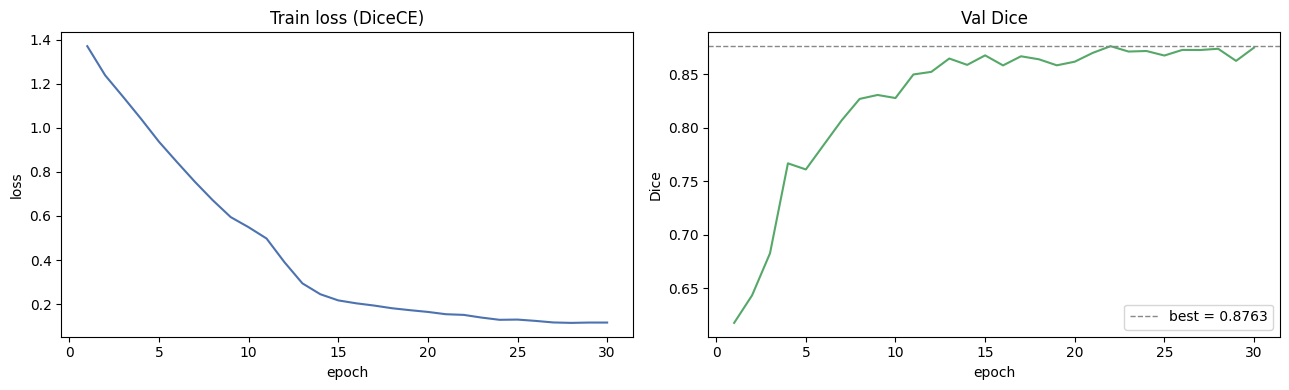

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(1, cfg.epochs + 1), train_losses, color="#4c72b0")
ax[0].set_title("Train loss (DiceCE)"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[1].plot(range(1, cfg.epochs + 1), val_dices, color="#55a868")
ax[1].set_title("Val Dice"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("Dice")
ax[1].axhline(best_dice, color="#888", linestyle="--", linewidth=1,
              label=f"best = {best_dice:.4f}")
ax[1].legend()
plt.tight_layout(); plt.show()


## 9. Inspecting predictions


### §9.1 — Loading the best checkpoint and overlaying predictions

**What this cell does:** Reloads the best-Dice checkpoint, runs the model on a handful of validation images, and shows image / ground-truth mask / predicted mask side by side.

**Why:** The Dice number is one summary scalar — it hides where the model is succeeding and failing. Visual overlays surface the actual failure modes: ragged boundaries, missed small lesions, false positives in shadow regions, posterior-acoustic-enhancement artefacts mistaken for tumor.

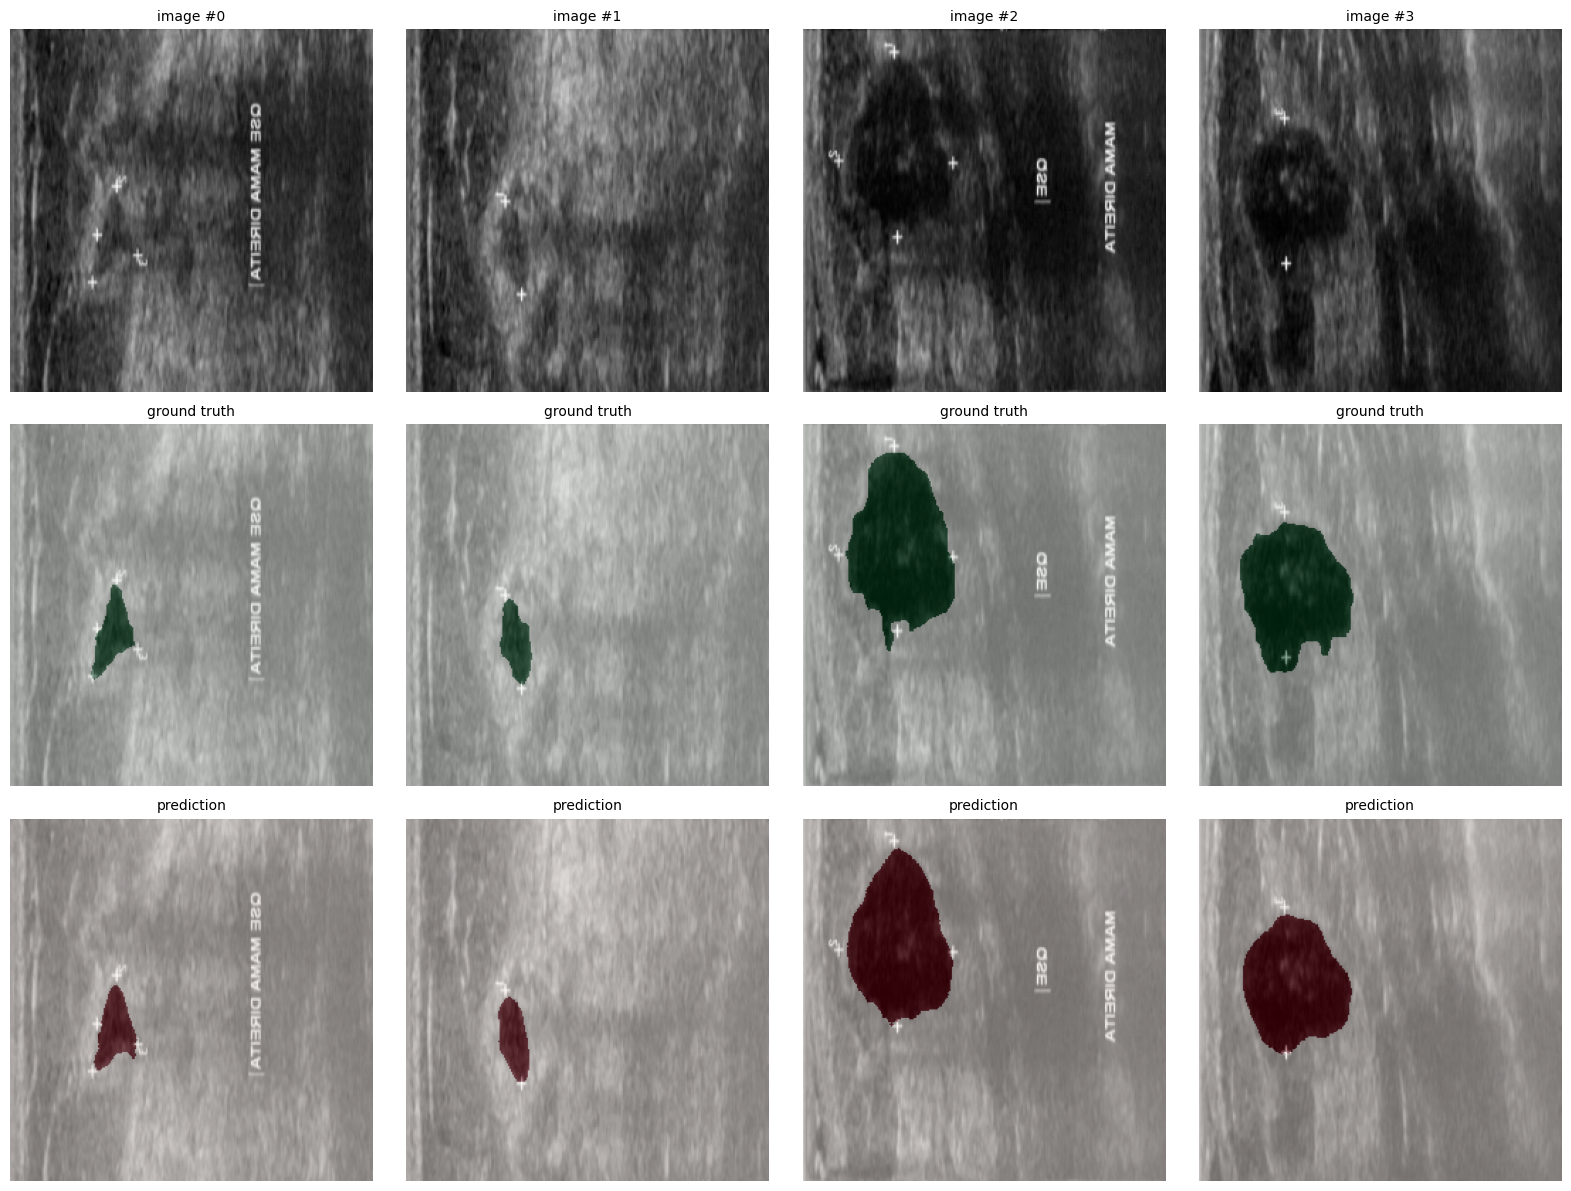

In [15]:
model.load_state_dict(torch.load(cfg.ckpt_path, map_location=DEVICE))
model.eval()

n_show = 4
batch = next(iter(val_loader))
img = batch["image"][:n_show].to(DEVICE)
lab = batch["label"][:n_show].to(DEVICE)

with torch.no_grad():
    logits = model(img)
pred = post_pred(logits)

img_np  = img.cpu().numpy()
lab_np  = lab.cpu().numpy()
pred_np = pred.cpu().numpy()

fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))
for j in range(n_show):
    axes[0, j].imshow(img_np[j, 0], cmap="gray")
    axes[0, j].set_title(f"image #{j}", fontsize=10); axes[0, j].axis("off")

    axes[1, j].imshow(img_np[j, 0], cmap="gray")
    axes[1, j].imshow(lab_np[j, 0], cmap="Greens", alpha=0.45)
    axes[1, j].set_title("ground truth", fontsize=10); axes[1, j].axis("off")

    axes[2, j].imshow(img_np[j, 0], cmap="gray")
    axes[2, j].imshow(pred_np[j, 0], cmap="Reds", alpha=0.45)
    axes[2, j].set_title("prediction", fontsize=10); axes[2, j].axis("off")

plt.tight_layout(); plt.show()


### §9.2 — Worst-Dice cases

**What this cell does:** Runs the best checkpoint over the entire validation fold, computes per-image Dice, sorts in ascending, and plots the four worst cases with image / ground-truth / prediction overlays.

**Why:** The random four samples in §9.1 show typical behaviour — most of them look good because most of the val set *is* good (mean Dice ≈ 0.88). The worst cases are where the model is actually failing, and those are what tell you what to fix next.

Common patterns to look for in the bottom-of-the-distribution overlays:

- **Miss / near-miss.** Predicted mask is tiny or absent → the model failed to localise the lesion at all. Often correlates with very small, very deep, or very low-contrast lesions.
- **Wrong region.** Predicted mask is on a different structure (a rib shadow, a duct, a cyst wall) → confusable non-tumor anatomy.
- **Over-segmentation.** Predicted mask sprawls beyond the tumor into surrounding tissue → boundary ambiguity dominating.
- **Under-segmentation.** Predicted mask sits inside the GT contour → the boundary-conservative behaviour seen in §9.1, but more extreme.

Each pattern points to a different next fix (better augmentation, different loss weighting, resolution changes, or class-conditioned training), so the *type* of failure matters more than the Dice number.

Val cases scored: 376
Dice range      : 0.3149 (worst) → 0.9809 (best)
Mean val Dice   : 0.8763


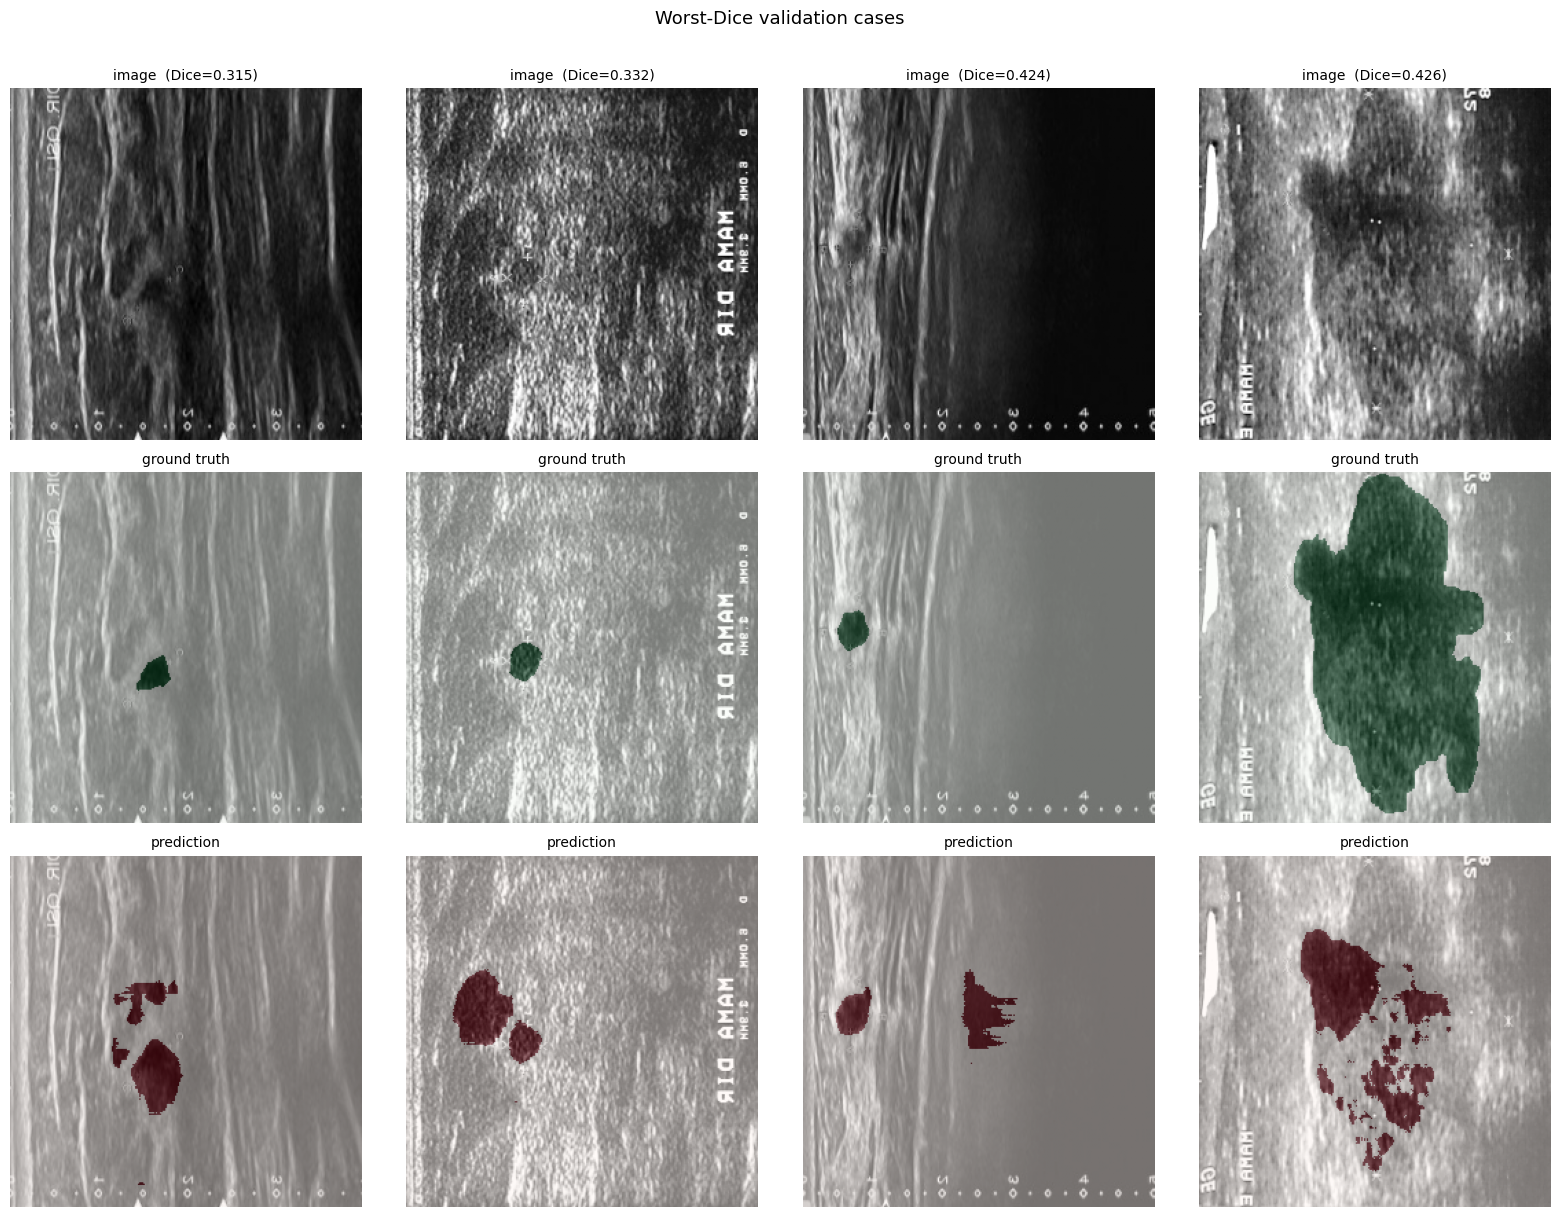

In [16]:
from monai.metrics import DiceMetric

# --- Per-image Dice over the entire val set ---
per_image_metric = DiceMetric(include_background=True, reduction="none")
model.eval()
per_image_dice, records = [], []

with torch.no_grad():
    for batch in val_loader:
        img = batch["image"].to(DEVICE, non_blocking=True)
        lab = batch["label"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(cfg.use_amp and DEVICE.type == "cuda")):
            logits = model(img)
        pred = post_pred(logits)
        d = per_image_metric(y_pred=pred, y=lab)  # shape (B, 1)
        for i in range(img.size(0)):
            records.append({
                "image": img[i, 0].cpu().numpy(),
                "gt":    lab[i, 0].cpu().numpy(),
                "pred":  pred[i, 0].cpu().numpy(),
                "dice":  float(d[i, 0].item()),
            })

# --- Sort ascending: worst first ---
records.sort(key=lambda r: r["dice"])

print(f"Val cases scored: {len(records)}")
print(f"Dice range      : {records[0]['dice']:.4f} (worst) "
      f"→ {records[-1]['dice']:.4f} (best)")
print(f"Mean val Dice   : {np.mean([r['dice'] for r in records]):.4f}")

# --- Plot the 4 worst ---
n_show = 4
worst = records[:n_show]

fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))
for j, r in enumerate(worst):
    axes[0, j].imshow(r["image"], cmap="gray")
    axes[0, j].set_title(f"image  (Dice={r['dice']:.3f})", fontsize=10)
    axes[0, j].axis("off")

    axes[1, j].imshow(r["image"], cmap="gray")
    axes[1, j].imshow(r["gt"], cmap="Greens", alpha=0.45)
    axes[1, j].set_title("ground truth", fontsize=10); axes[1, j].axis("off")

    axes[2, j].imshow(r["image"], cmap="gray")
    axes[2, j].imshow(r["pred"], cmap="Reds", alpha=0.45)
    axes[2, j].set_title("prediction", fontsize=10); axes[2, j].axis("off")

plt.suptitle("Worst-Dice validation cases", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Summary

A self-contained, config-driven, MONAI-only segmentation pipeline for BUS-BRA:

* Dataset auto-located (with a `kagglehub` fallback) and split via the predefined `K5P` patient-grouped 5-fold assignment — no patient leakage by construction.
* Dictionary transforms: load → channel-first → scale intensity → binarise label → resize 256×256 → light horizontal-flip augmentation (training only).
* MONAI `UNet` (1.6M parameters) trained with `DiceCELoss` — the loss choice is a direct consequence of the quality-check snapshot's class-balance gate (background : foreground ≈ 10.6 : 1). Mixed-precision training with `torch.amp`, best-Dice checkpointing over 30 epochs.
* Validation with `DiceMetric` over thresholded sigmoid predictions, plus a visual prediction overlay for qualitative inspection.

### Results (K5P fold 1, 376 val cases)

* **Best validation Dice: 0.876** (mean per-image Dice on the same fold: 0.876; range 0.315 → 0.981).
* Training loss decreases monotonically to ~0.12; val Dice plateaus around epoch 22.
* Only 4 of 376 val cases (~1%) score below 0.5.
* **Dominant failure mode in the worst cases: fragmented predictions** (multiple disconnected components) where BUS-BRA ground truth is always a single connected component — a free post-processing signal for the next iteration.

### What this pipeline is and isn't

This is a **single-fold baseline** — one training run on one K5P fold. A trustworthy headline number needs the loop across all five folds and a held-out test set via `HOP`. 
